**Regularisation is this technique using which, you induce some "added information" in a machine learning model so that you can reduce overfitting**

*To regularise -> meaning if something is more, make it less, use it whenever you feel there is a chance of overfitting*

Apply ridge regression when you have 2 or more than 2 input columns.

Regularisation term is added which helps prevent overfitting

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [27]:
from sklearn.datasets import load_diabetes
data = load_diabetes()

In [28]:
print(data.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

*we have 10 input cols and 1 output coln*

In [29]:
data.data.shape

(442, 10)

In [30]:
data.target.shape

(442,)

In [31]:
X = data.data
y = data.target

In [32]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=45
)

In [33]:
from sklearn.linear_model import LinearRegression
L = LinearRegression()

In [34]:
L.fit(X_train,y_train)

LinearRegression()

*case of multiple linear regression*

In [35]:
print(L.coef_)
print(L.intercept_)

[  23.45465406 -247.42747406  492.1087518   329.35876431 -970.79723039
  573.54295519  182.42162368  255.92168168  794.21609282   89.32249214]
152.13623331746496


In [36]:
y_pred = L.predict(X_test)

In [37]:
from sklearn.metrics import r2_score,mean_squared_error
print("R2 score",r2_score(y_test,y_pred))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred)))


R2 score 0.5188113124539249
RMSE 48.72713760953253


alpha is inversely proportional to the coefficients

high m -> overfitting -> low alpha

low m -> underfitting -> high alpha

optimum between high m and low m -> i.e where bias is high and variance is low
(error made by line for training pts = error made by line for testing pts)
variance = difference btw errors in training and testing -> (10-15)

let us say if the line exactly passed through the training points, then the error made by the line for the training points is 0, and let us assume error made by line for testing points is 90, then variance is (90-0) = 90 variance very high, i.e the results are completely different for train and test, where it performs exceptionally well on train, but not on test.

So we choose a line that might make mistakes on training points but the training and test points error is almost comparable which mean variance is low -> performs reasonably same on both train and test.

In [38]:
from sklearn.linear_model import Ridge
R = Ridge(
    alpha=100000
)
R.fit(X_train,y_train)

Ridge(alpha=100000)

In [39]:
print(R.coef_)
print(R.intercept_)

[ 0.00260126  0.00057066  0.00776597  0.0060976   0.00233864  0.00184724
 -0.00513942  0.0052716   0.00734598  0.00528629]
151.83287930791352


In [40]:
y_pred1 = R.predict(X_test)

In [41]:
print("R2 score",r2_score(y_test,y_pred1))
print("RMSE",np.sqrt(mean_squared_error(y_test,y_pred1)))

R2 score -0.00042490200441935855
RMSE 70.25956272917782


Reg line is worst than the mean line

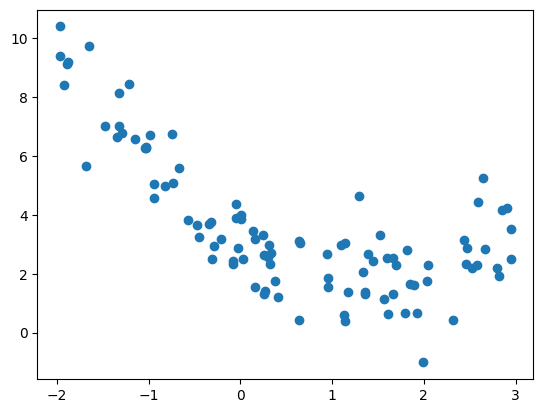

In [42]:
m = 100
x1 = 5 * np.random.rand(m, 1) - 2
x2 = 0.7*x1**2 - 2*x1 + 3 + np.random.randn(m,1)
plt.scatter(x1,x2)
plt.show()

In [43]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

      1. include overfitting by extracting the
      higher degree polynomial features from the input column
      
      2. then apply ridge regression to reduce overfitting

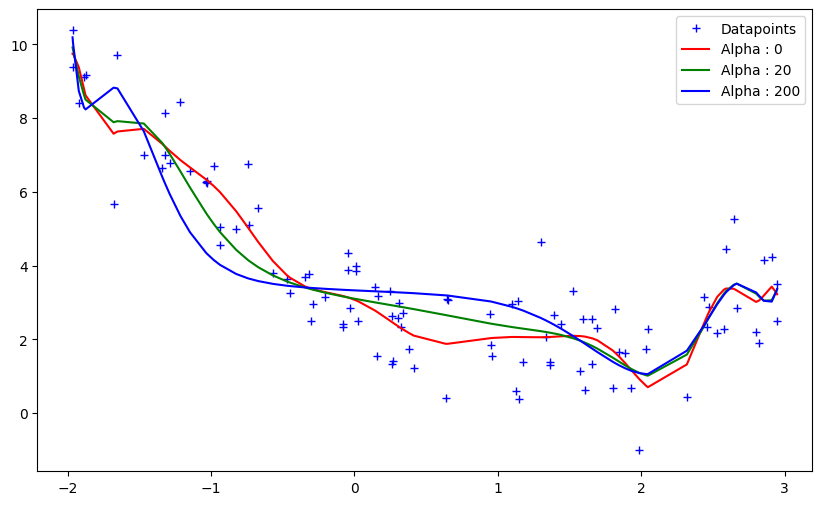

In [44]:
def get_preds_ridge(x1, x2, alpha):
  model = Pipeline([
      ('poly_feats',PolynomialFeatures(degree=16)),
      ('ridge', Ridge(alpha=alpha))
  ])
  model.fit(x1,x2)
  return model.predict(x1)

alphas = [0, 20, 200]
cs = ['r', 'g', 'b']

plt.figure(figsize=(10, 6))
plt.plot(x1,x2,'b+', label='Datapoints')

for alpha, c in zip(alphas,cs):
  preds = get_preds_ridge(x1,x2,alpha)
  # Plot
  plt.plot(sorted(x1[:,0]), preds[
      np.argsort(x1[:,0])
  ], c, label = 'Alpha : {}'.format(alpha))

plt.legend()
plt.show()

Blue -> underfitting

Red -> overfitting

Green -> optimum

np.argsort will give the indices of the sorted values